In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import corner

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import pearsonr, spearmanr

plt.rcParams.update({'font.size': 12})

In [3]:
ucni_set_parametri_path = 'C:\\Users\\tadej\\Desktop\\STUDIJ\\mag-2.letnik\\PSUF\\PSUF2\\data\\UcniSetParametri.txt'
ucni_set_tipi_path = 'C:\\Users\\tadej\\Desktop\\STUDIJ\\mag-2.letnik\\PSUF\\PSUF2\\data\\UcniSetTipi.txt'
val_path = "C:\\Users\\tadej\\Desktop\\STUDIJ\\mag-2.letnik\\PSUF\\PSUF2\\data\\spektri\\val.dat"
spektri_path = "C:\\Users\\tadej\\Desktop\\STUDIJ\\mag-2.letnik\\PSUF\\PSUF2\\data\\spektri\\{}.dat"

ucni_set_parametri = pd.read_csv(ucni_set_parametri_path, delimiter=' ')
ucni_set_tipi = pd.read_csv(ucni_set_tipi_path, delimiter=' ')

types = ucni_set_tipi['type'].unique()
specters = {}

for typ in types:
    specters[typ] = ucni_set_tipi.loc[ucni_set_tipi['type'] == typ, '#spekter'].values - 1

In [4]:
# load wavelengths file
wav = np.loadtxt(val_path, comments='#')
n = 10000

# load spectra in a loop
spectra_array=[]
for spectrum in range(1, n+1):
    flux = np.loadtxt(spektri_path.format(spectrum), comments='#')
    spectra_array.append(flux)

# create an array
X = np.array(spectra_array)

## Učni set

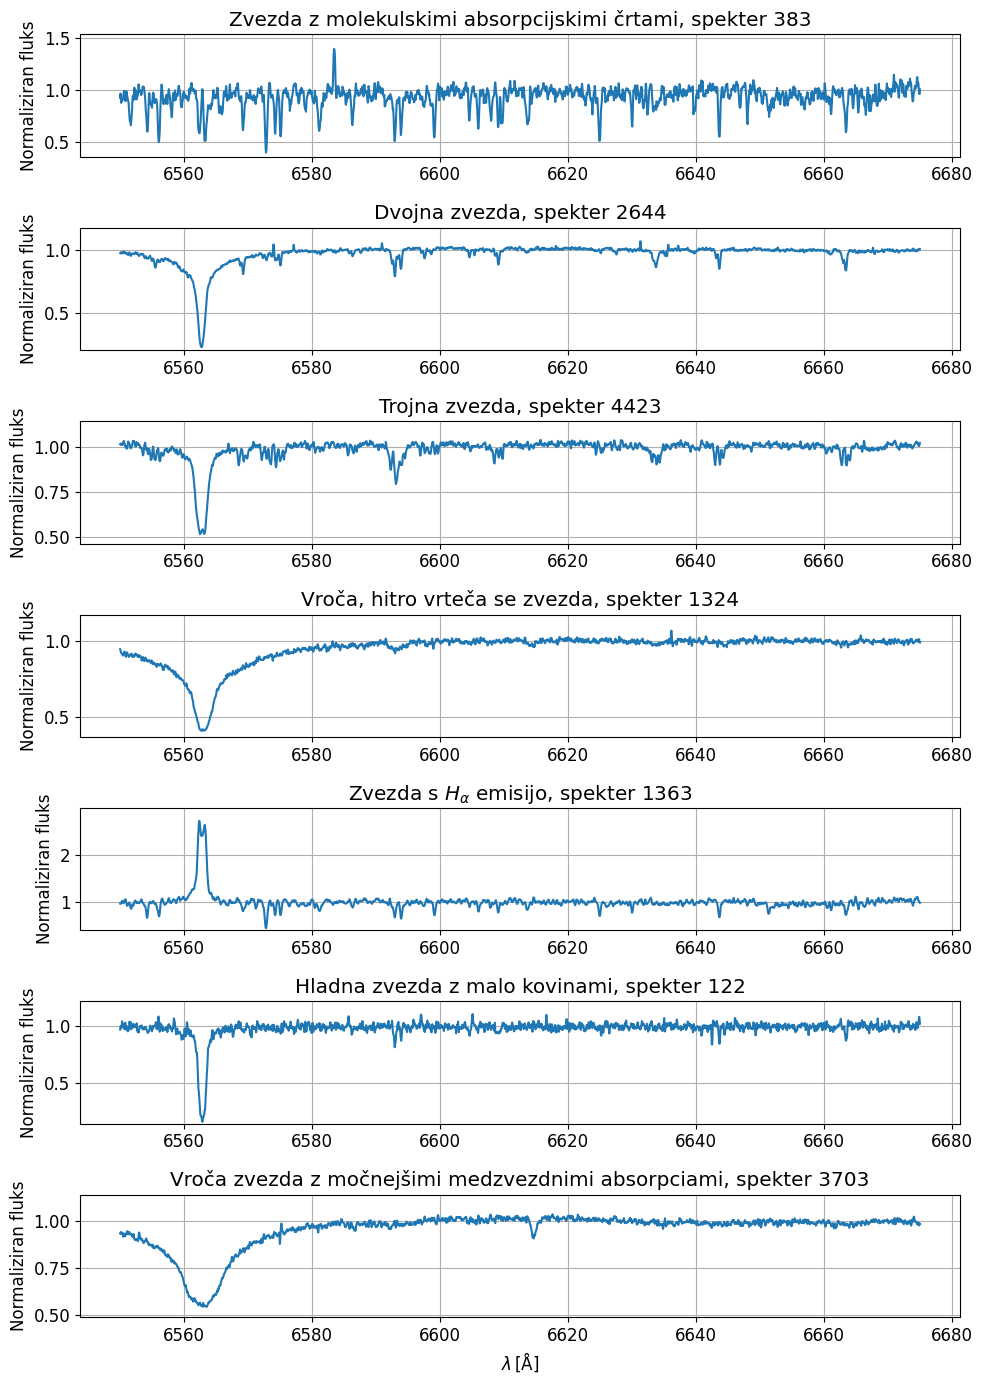

In [21]:
stars = {
    "MAB": (383, "Zvezda z molekulskimi absorpcijskimi črtami"),
    "BIN": (2644, "Dvojna zvezda"),
    "TRI": (4423, "Trojna zvezda"),
    "HFR": (1324, "Vroča, hitro vrteča se zvezda"),
    "HAE": (1363, r"Zvezda s $H_\alpha$ emisijo"),
    "CMP": (122, "Hladna zvezda z malo kovinami"),
    "DIB": (3703,"Vroča zvezda z močnejšimi medzvezdnimi absorpciami")
}

fig, axes = plt.subplots(7, 1, figsize=(10, 14))

for i, ax in enumerate(axes):
    star_type = list(stars.keys())[i]
    specter = spectra_array[stars[star_type][0] - 1]
    ax.plot(wav, specter)
    ax.set_title(f"{stars[star_type][1]}, spekter {stars[star_type][0]}")
    ax.grid(True)
    ax.set_ylabel("Normaliziran fluks")
    ax.set_ylim((np.min(specter)*0.9, np.max(specter)*1.1))
    if i == 6:
        ax.set_xlabel(r"$\lambda \, [\mathrm{\AA}]$")

plt.tight_layout()
plt.show()

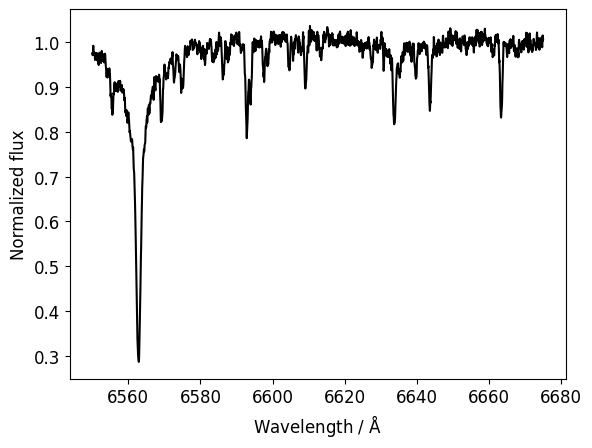

In [22]:
# plot spectrum
plt.plot(wav, spectra_array[4036 - 1], 'k-')
plt.xlabel(r'Wavelength / $\mathrm{\AA}$')
plt.ylabel(r'Normalized flux')
plt.show()

## Implementacija PCA

In [23]:
def PCA(X, eta):
    u = X.mean(axis=0) # Povprečja stolpcev
    B = X - u # Centriranje
    C = 1 / (n-1) * B.T @ B
    eigvals, eigvecs = np.linalg.eigh(C) # Lastni razcep

    # sortiramo po padajoči vrednosti (večja varianca prva)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx] # (p,) padajoče
    V = eigvecs[:, idx] # (p, p) stolpci = lastni vektorji

    # kumulativna energija in delež
    cum_energy = np.cumsum(eigvals) # g_j
    total_energy = cum_energy[-1] # G
    frac = cum_energy / total_energy # frakcija razložene variance do j-te komponente

    # najdi najmanjše q za dano mejo eta
    q = int(np.searchsorted(frac, eta) + 1) # +1, ker indeksi začnejo pri 0, j pa pri 1

    print(f"Za {eta*100:.1f}% energije potrebujemo q = {q} komponent.")

    # Redukcija dimenzij
    W = V[:, :q]
    T = X @ W

    return T, eigvals, frac

eta = 0.9
T, eigvals, frac = PCA(X, eta)

Za 90.0% energije potrebujemo q = 101 komponent.


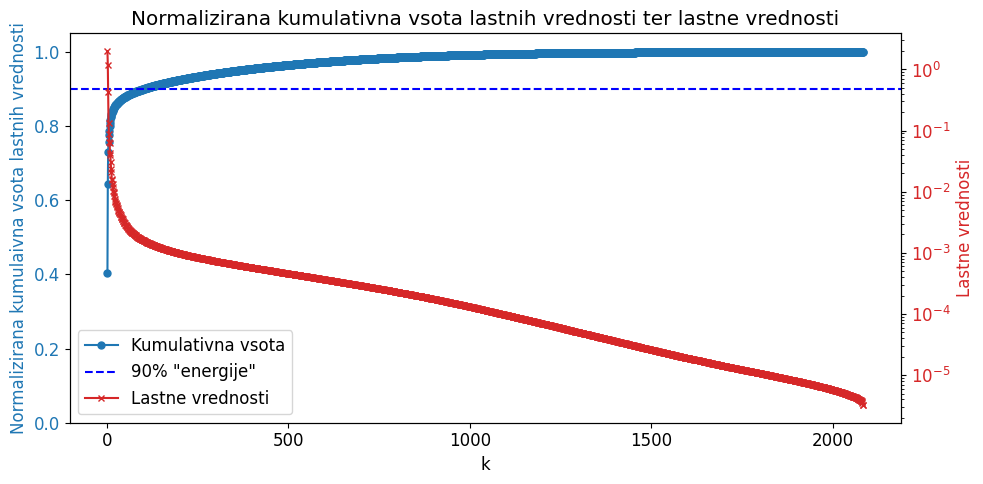

In [24]:
# predpostavka: frac in eigvals_sorted sta že definirana
x = np.arange(1, len(frac)+1)  # indeksi komponent (1..p)

fig, ax1 = plt.subplots(figsize=(10,5))

# leva y-os: kumulativna frakcija
color1 = 'tab:blue'
ax1.set_xlabel('k')
ax1.set_ylabel('Normalizirana kumulaivna vsota lastnih vrednosti', color=color1)
ax1.plot(x, frac, marker='o', markersize=5, color=color1, label='Kumulativna vsota')
ax1.axhline(eta, color='blue', linestyle='--', label='90% "energije"')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0,1.05)

# desna y-os: lastne vrednosti
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Lastne vrednosti', color=color2)
ax2.plot(x, eigvals, marker='x', markersize=5, color=color2, label='Lastne vrednosti')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_yscale('log')

# skupna legenda
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title('Normalizirana kumulativna vsota lastnih vrednosti ter lastne vrednosti')
plt.tight_layout()
plt.show()

C:\Users\tadej\AppData\Local\Temp\ipykernel_10416\812794913.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


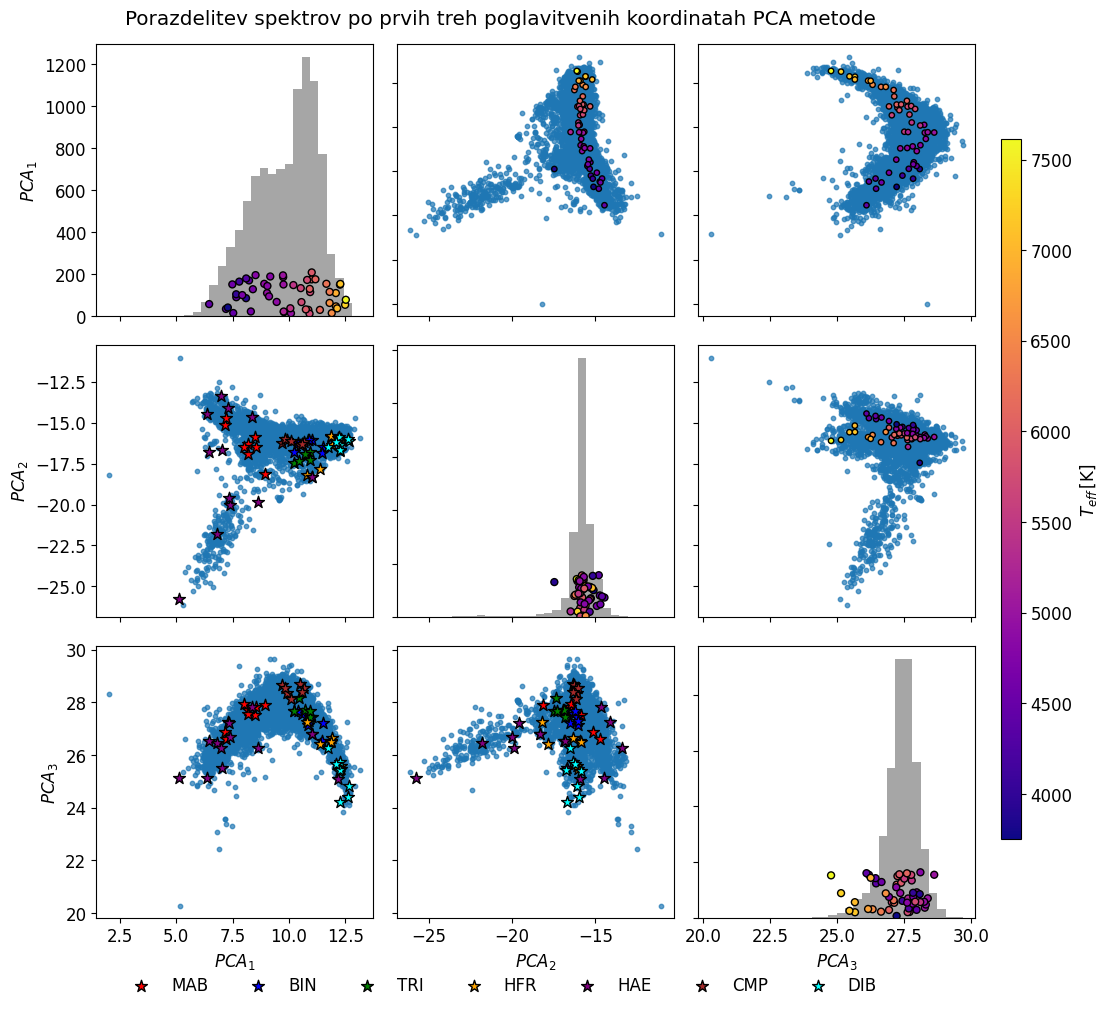

In [25]:
# Prikažemo tri glavne komponente
q_plot = min(3, T.shape[1])
T_plot = T[:, :q_plot]
colors = {
    'MAB': 'red',
    'BIN': 'blue',
    'TRI': 'green',
    'HFR': 'orange',
    'HAE': 'purple',
    'CMP': 'brown',
    'DIB': 'cyan'
}
specters_params = ucni_set_parametri['#spekter'].values - 1
num = np.shape(specters_params)[0]
Teff_values = ucni_set_parametri['Teff'].values

fig, axes = plt.subplots(q_plot, q_plot, figsize=(10, 10))
# ✅ Glavni naslov nad celotno sliko
fig.suptitle('Porazdelitev spektrov po prvih treh poglavitvenih koordinatah PCA metode')

for i in range(q_plot):
    for j in range(q_plot):
        ax = axes[i, j]

        if i == j:
            # Diagonal – histogram of each component
            if i == 0:
                a = 200
            elif i == 1:
                a = 800
            elif i == 2:
                a = 400
            ax.hist(T_plot[:, i], bins=30, color='gray', alpha=0.7)
            sc_logg = ax.scatter(T_plot[specters_params, i], np.random.rand(num)*a + 12,
                                 c=Teff_values, cmap='plasma', s=25, edgecolor='k')
        else:
            # Off-diagonal – scatter plot
            ax.scatter(T_plot[:, j], T_plot[:, i], s=10, alpha=0.7)
            if i > j:
                for typ in types:
                    ax.scatter(T_plot[specters[typ], j], T_plot[specters[typ], i],
                               s=80, label=typ, edgecolor='k', marker='*', color=colors[typ])
            if i < j:
                sc = ax.scatter(T_plot[specters_params, j], T_plot[specters_params, i],
                                c=Teff_values, cmap='plasma', s=15, edgecolor='k')

        # Label axes only on left and bottom
        if j == 0:
            ax.set_ylabel(rf'$PCA_{{{i+1}}}$')
        else:
            ax.set_yticklabels([])

        if i == q_plot - 1:
            ax.set_xlabel(rf'$PCA_{{{j+1}}}$')
        else:
            ax.set_xticklabels([])

# Zberi handles in labels iz vseh axes (ohrani vrstni red in unikatnost)
all_handles = []
all_labels = []
for a in axes.flat:
    h, l = a.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in all_labels:
            all_labels.append(ll)
            all_handles.append(hh)

# Če ni nobenega label-a, ne delaj nič
if len(all_handles) > 0:
    # naredimo prostor spodaj za legendo
    plt.subplots_adjust(bottom=0.15)   # prilagodi po potrebi (večja vrednost = več prostora)
    # ncol nastaviš na število različnih tipov, vendar omeji, da se legenda ne raztegne preveč vertikalno
    ncol = min(len(all_labels), 10)     # npr. največ 8 stolpcev, prilagodi po želji

    # postavi legendo pod graf (horizontalno, centrirano)
    fig.legend(all_handles, all_labels,
               loc='lower center',
               bbox_to_anchor=(0.5, -0.02),
               ncol=ncol,
               frameon=False)

# določimo pozicijo in velikost barve: [x0, y0, širina, višina] v figure koordinatah
cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])  # x0, y0, width, height
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label(r'$T_{eff} \, \text{[K]}$')

plt.tight_layout()
plt.show()

C:\Users\tadej\AppData\Local\Temp\ipykernel_10416\2708320226.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


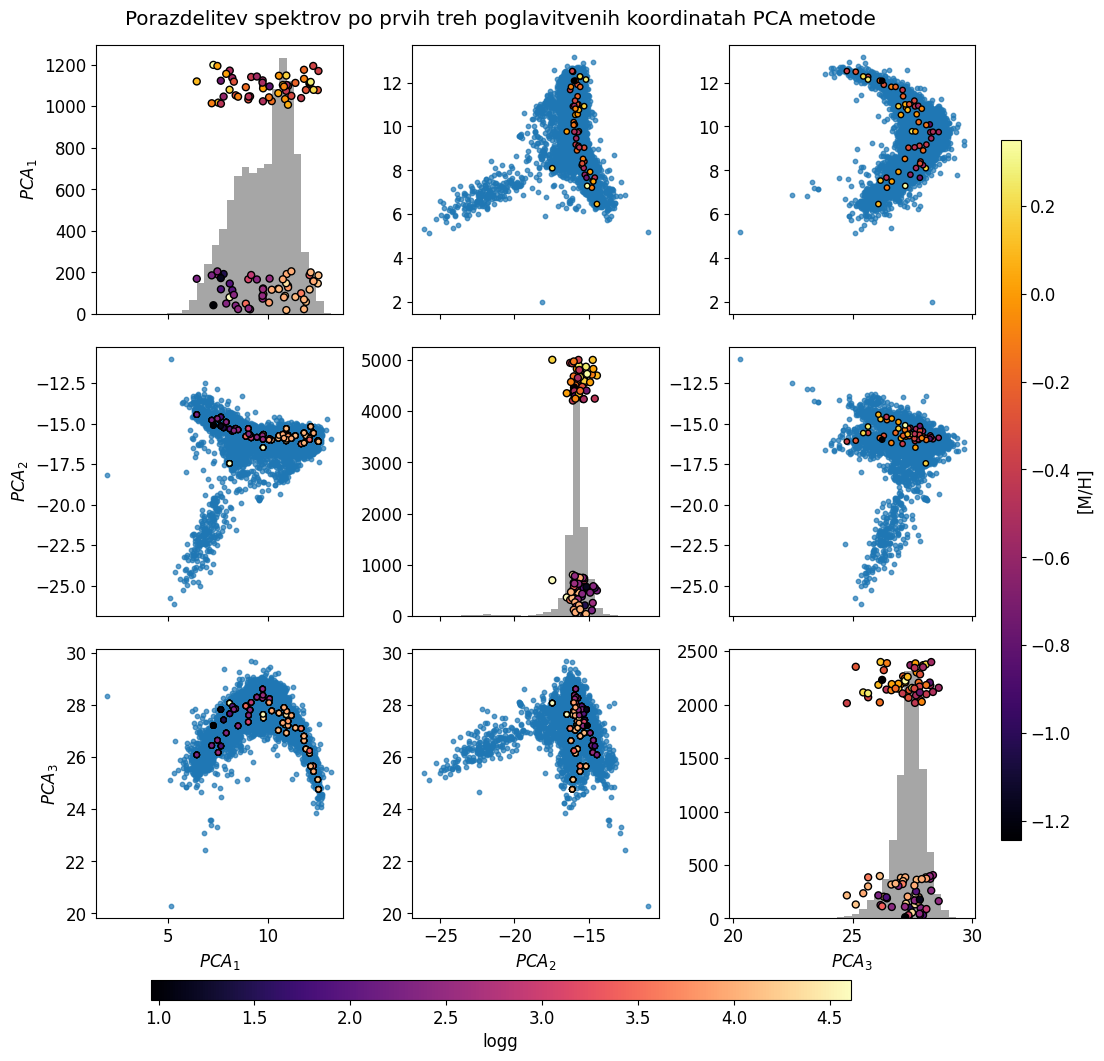

In [26]:
# Prikažemo tri glavne komponente
q_plot = min(3, T.shape[1])
T_plot = T[:, :q_plot]
specters_params = ucni_set_parametri['#spekter'].values - 1
num = np.shape(specters_params)[0]
logg_values = ucni_set_parametri['logg'].values
MH_values = ucni_set_parametri['[M/H]'].values

fig, axes = plt.subplots(q_plot, q_plot, figsize=(10, 10))
# ✅ Glavni naslov nad celotno sliko
fig.suptitle('Porazdelitev spektrov po prvih treh poglavitvenih koordinatah PCA metode')

for i in range(q_plot):
    for j in range(q_plot):
        ax = axes[i, j]

        if i == j:
            # Diagonal – histogram of each component
            if i == 0:
                a = 200
                b = 1200
            elif i == 1:
                a = 800
                b = 5000
            elif i == 2:
                a = 400
                b = 2400
            ax.hist(T_plot[:, i], bins=30, color='gray', alpha=0.7)
            sc_logg = ax.scatter(T_plot[specters_params, i], np.random.rand(num)*a + 12,
                                 c=logg_values, cmap='magma', s=25, edgecolor='k')
            sc_MH = ax.scatter(T_plot[specters_params, i], np.random.rand(num)*a + (b-a),
                                 c=MH_values, cmap='inferno', s=25, edgecolor='k')
        else:
            # Off-diagonal – scatter plot
            ax.scatter(T_plot[:, j], T_plot[:, i], s=10, alpha=0.7)
            if i > j:
                for typ in types:
                    sc_logg = ax.scatter(T_plot[specters_params, j], T_plot[specters_params, i],
                                    c=logg_values, cmap='magma', s=15, edgecolor='k')
            if i < j:
                sc_MH = ax.scatter(T_plot[specters_params, j], T_plot[specters_params, i],
                                c=MH_values, cmap='inferno', s=15, edgecolor='k')

        # Label axes only on left and bottom
        if j == 0:
            ax.set_ylabel(rf'$PCA_{{{i+1}}}$')

        if i == q_plot - 1:
            ax.set_xlabel(rf'$PCA_{{{j+1}}}$')
        else:
            ax.set_xticklabels([])


cbar_ax = fig.add_axes([0.15, -0.01, 0.7, 0.02])  # [x0, y0, width, height]
cbar = fig.colorbar(sc_logg, cax=cbar_ax, orientation='horizontal')
cbar.set_label(r'logg')

# določimo pozicijo in velikost barve: [x0, y0, širina, višina] v figure koordinatah
cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])  # x0, y0, width, height
cbar = fig.colorbar(sc_MH, cax=cbar_ax)
cbar.set_label('[M/H]')

plt.tight_layout()
plt.show()

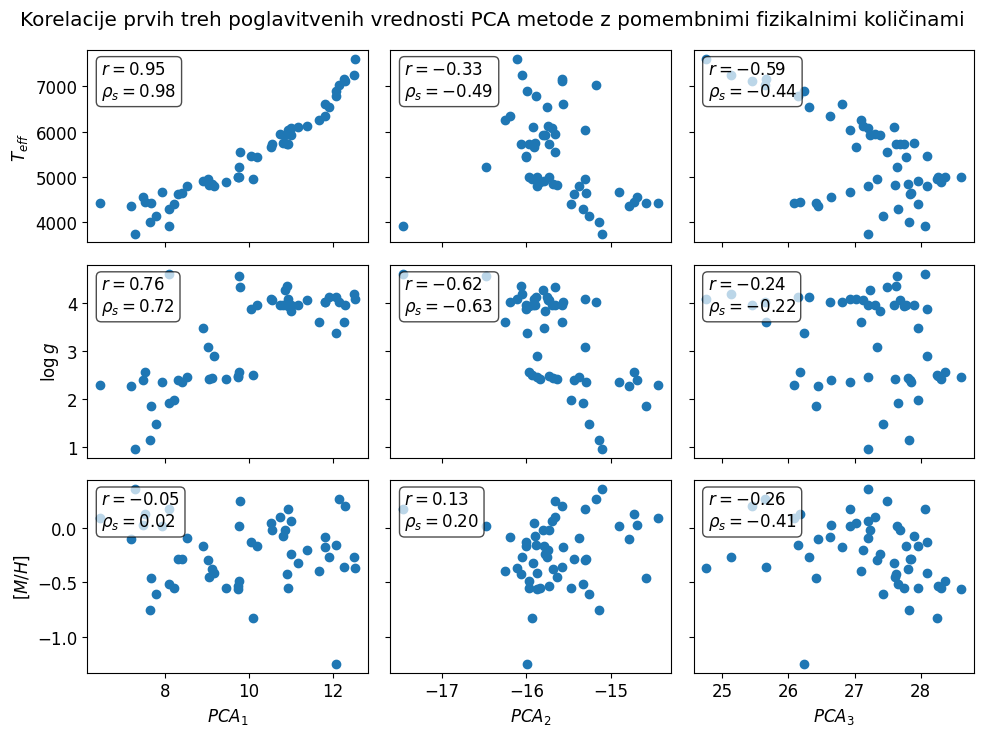

In [43]:
# Prikažemo tri glavne komponente
q_plot = min(3, T.shape[1])
T_plot = T[:, :q_plot]
specters_params = ucni_set_parametri['#spekter'].values - 1
T_plot_params = T_plot[specters_params, :]
num = np.shape(specters_params)[0]
Teff_values = ucni_set_parametri['Teff'].values
logg_values = ucni_set_parametri['logg'].values
MH_values = ucni_set_parametri['[M/H]'].values

fig, axes = plt.subplots(q_plot, q_plot, figsize=(10, 7.5))
# ✅ Glavni naslov nad celotno sliko
fig.suptitle('Korelacije prvih treh poglavitvenih vrednosti PCA metode z pomembnimi fizikalnimi količinami')

for i in range(q_plot):

    if i == 0:
        values = Teff_values
        ylabel = r'$T_{eff}$'
    elif i == 1:
        values = logg_values
        ylabel = r'$\log{g}$'
    elif i == 2:
        values = MH_values
        ylabel = r'$[M/H]$'

    for j in range(q_plot):
        ax = axes[i, j]
        pearson_corr = pearsonr(T_plot_params[:, j], values)[0]
        spearman_corr = spearmanr(T_plot_params[:, j], values)[0]
        ax.scatter(T_plot_params[:, j], values)

        # 🔹 Dodaj textbox z obema korelacijama
        textstr = '\n'.join((
            rf'$r = {pearson_corr:.2f}$',
            rf'$\rho_s = {spearman_corr:.2f}$'
        ))

        ax.text(0.05, 0.95, textstr, transform=ax.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

        # Label axes only on left and bottom
        if j == 0:
            ax.set_ylabel(ylabel)
        else:
            ax.set_yticklabels([])

        if i == q_plot - 1:
            ax.set_xlabel(rf'$PCA_{{{j+1}}}$')
        else:
            ax.set_xticklabels([])

plt.tight_layout()
plt.show()

In [28]:
q = np.shape(T[0])[0]
pearson_corr_Teff = np.zeros(q)
spearman_corr_Teff = np.zeros(q)
pearson_corr_logg = np.zeros(q)
spearman_corr_logg = np.zeros(q)
pearson_corr_MH = np.zeros(q)
spearman_corr_MH = np.zeros(q)
T_params = T[specters_params, :]

for i in range(q):
    pearson_corr_Teff[i] = pearsonr(T_params[:, i], Teff_values)[0]
    spearman_corr_Teff[i] = spearmanr(T_params[:, i], Teff_values)[0]
    pearson_corr_logg[i] = pearsonr(T_params[:, i], logg_values)[0]
    spearman_corr_logg[i] = spearmanr(T_params[:, i], logg_values)[0]
    pearson_corr_MH[i] = pearsonr(T_params[:, i], MH_values)[0]
    spearman_corr_MH[i] = spearmanr(T_params[:, i], MH_values)[0]

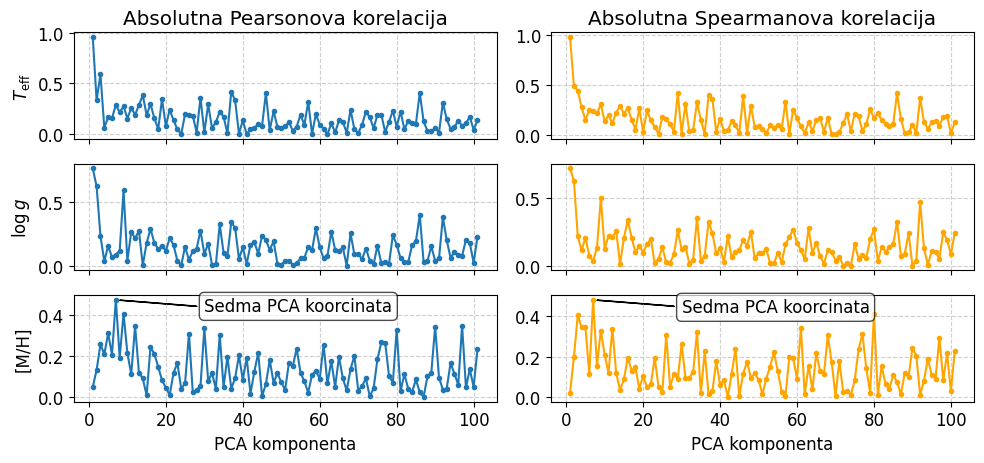

In [40]:
x = np.arange(1, q + 1)

fig, axes = plt.subplots(3, 2, figsize=(10, 5), sharex=True)
# fig.suptitle("Absolutne korelacije med poglavitnimi komponentami in fizikalnimi količinami")

# --- Prva vrstica: Teff ---
axes[0, 0].plot(x, np.abs(pearson_corr_Teff), '-o', markersize=3)
axes[0, 0].set_ylabel(r'$T_{\mathrm{eff}}$')
axes[0, 0].set_title("Absolutna Pearsonova korelacija")
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

axes[0, 1].plot(x, np.abs(spearman_corr_Teff), '-o', color='orange', markersize=3)
axes[0, 1].set_title("Absolutna Spearmanova korelacija")
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# --- Druga vrstica: logg ---
axes[1, 0].plot(x, np.abs(pearson_corr_logg), '-o', markersize=3)
axes[1, 0].set_ylabel(r'$\log g$')
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

axes[1, 1].plot(x, np.abs(spearman_corr_logg), '-o', color='orange', markersize=3)
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

# --- Tretja vrstica: [M/H] ---
axes[2, 0].plot(x, np.abs(pearson_corr_MH), '-o', markersize=3)
axes[2, 0].set_ylabel(r'[M/H]')
axes[2, 0].set_xlabel('PCA komponenta')
axes[2, 0].grid(True, linestyle='--', alpha=0.6)
axes[2, 0].arrow(8, 0.475, 20, -0.03)
axes[2, 0].text(30, 0.42, "Sedma PCA koorcinata",
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

axes[2, 1].plot(x, np.abs(spearman_corr_MH), '-o', color='orange', markersize=3)
axes[2, 1].set_xlabel('PCA komponenta')
axes[2, 1].grid(True, linestyle='--', alpha=0.6)
axes[2, 1].arrow(8, 0.48, 20, -0.03)
axes[2, 1].text(30, 0.42, "Sedma PCA koorcinata",
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout(rect=[0, 0, 1, 0.96])  # prostor za glavni naslov
plt.show()


C:\Users\tadej\AppData\Local\Temp\ipykernel_10416\3539508026.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


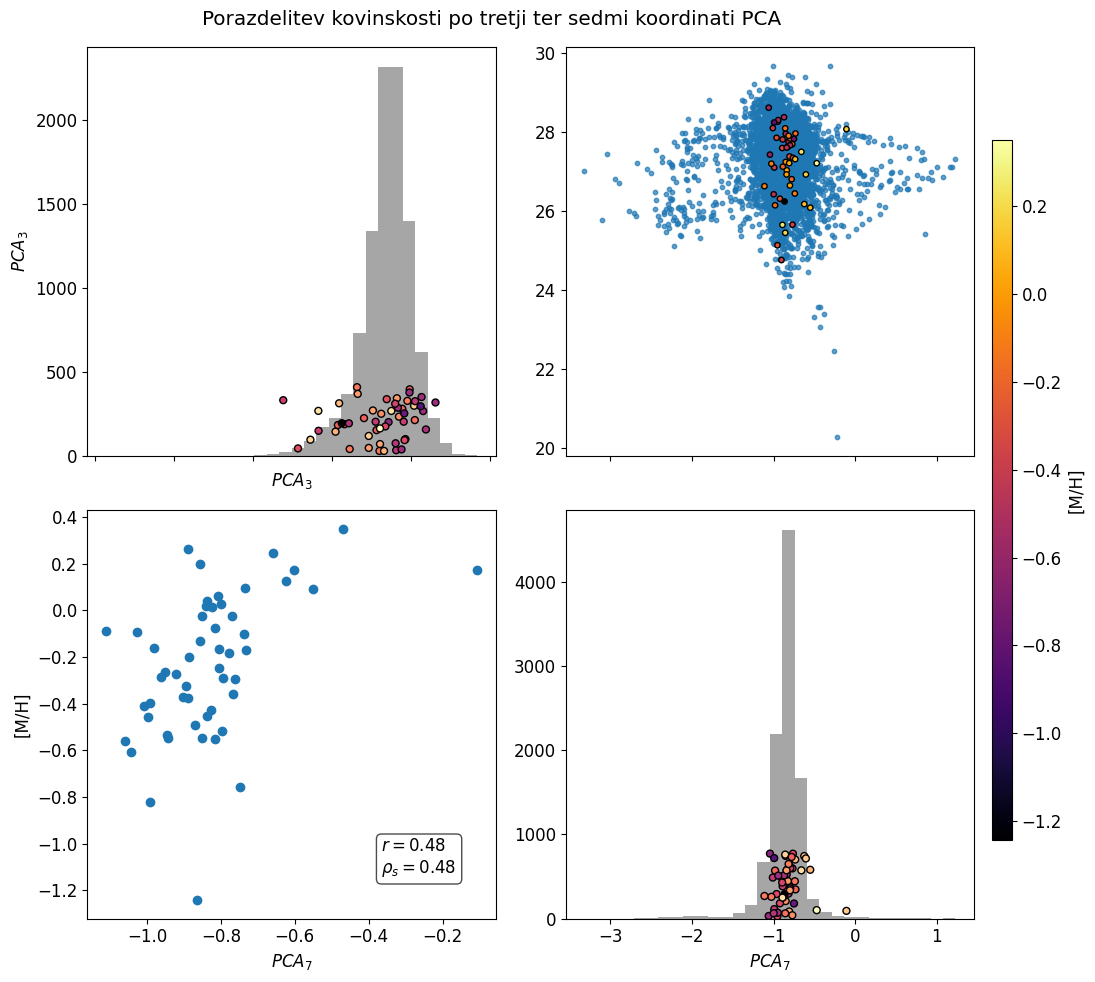

In [49]:
# Prikažemo tri glavne komponente
q_plot = min(2, T.shape[1])
T_plot = T[:, [2, 6]] # Tretja, sedma in osemdeseta koordinata
specters_params = ucni_set_parametri['#spekter'].values - 1
num = np.shape(specters_params)[0]
logg_values = ucni_set_parametri['logg'].values
MH_values = ucni_set_parametri['[M/H]'].values
PCAs = [3, 7]

fig, axes = plt.subplots(q_plot, q_plot, figsize=(10, 10))
# ✅ Glavni naslov nad celotno sliko
fig.suptitle('Porazdelitev kovinskosti po tretji ter sedmi koordinati PCA')

for i in range(q_plot):
    for j in range(q_plot):
        ax = axes[i, j]

        if i == j:
            # Diagonal – histogram of each component
            if i == 0:
                a = 400
            elif i == 1:
                a = 800
            ax.hist(T_plot[:, i], bins=30, color='gray', alpha=0.7)
            sc_logg = ax.scatter(T_plot[specters_params, i], np.random.rand(num)*a + 12,
                                 c=MH_values, cmap='magma', s=25, edgecolor='k')
            ax.set_xlabel(rf'$PCA_{PCAs[i]}$')
        else:
            # Off-diagonal – scatter plot
            if i > j:
                ax.scatter(T_plot[specters_params, 1], MH_values)
                ax.set_ylabel(r'[M/H]')
                # 🔹 Dodaj textbox z obema korelacijama
                textstr = '\n'.join((
                    rf'$r = {pearson_corr_MH[6]:.2f}$',
                    rf'$\rho_s = {spearman_corr_MH[6]:.2f}$'
                ))
                ax.text(0.72, 0.2, textstr, transform=ax.transAxes,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
            if i < j:
                ax.scatter(T_plot[:, j], T_plot[:, i], s=10, alpha=0.7)

                sc_MH = ax.scatter(T_plot[specters_params, j], T_plot[specters_params, i],
                                c=MH_values, cmap='inferno', s=15, edgecolor='k')
        # Label axes only on left and bottom
        if j == 0 and i != 1:
            ax.set_ylabel(rf'$PCA_{PCAs[i]}$')

        if i == q_plot - 1:
            ax.set_xlabel(rf'$PCA_{PCAs[i]}$')
        else:
            ax.set_xticklabels([])


# določimo pozicijo in velikost barve: [x0, y0, širina, višina] v figure koordinatah
cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])  # x0, y0, width, height
cbar = fig.colorbar(sc_MH, cax=cbar_ax)
cbar.set_label('[M/H]')

plt.tight_layout()
plt.show()

C:\Users\tadej\AppData\Local\Temp\ipykernel_10416\413455249.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', frameon=False)


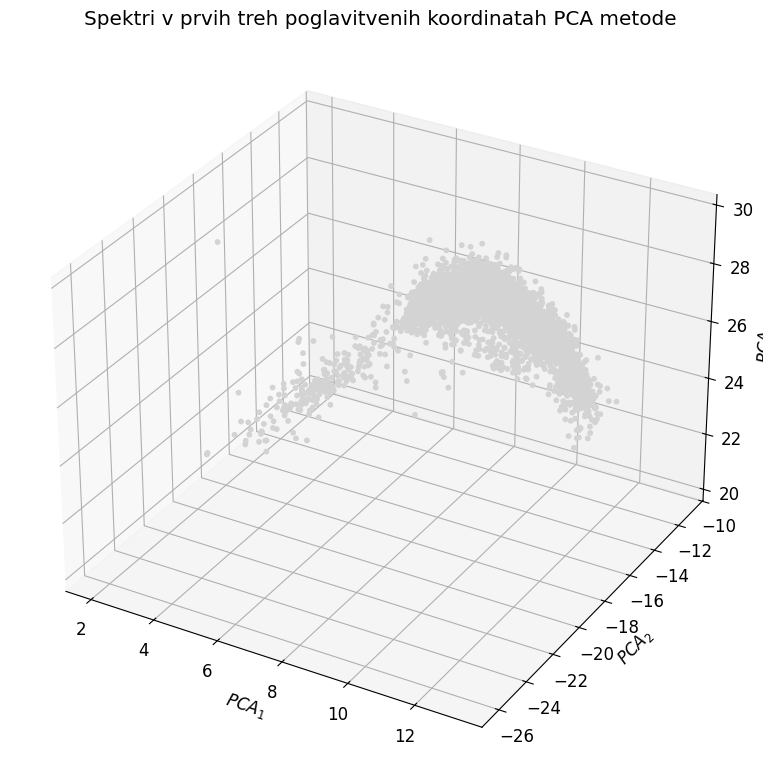

In [31]:
# Prikažemo le prve tri PCA komponente
q_plot = min(3, T.shape[1])
T_plot = T[:, :q_plot]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter vseh točk, barvane glede na temperaturo
sc = ax.scatter(
    T_plot[:, 0], T_plot[:, 1], T_plot[:, 2],
    c='lightgray', alpha=1, s=10
)

# Osi
ax.set_xlabel(r'$PCA_1$')
ax.set_ylabel(r'$PCA_2$')
ax.set_zlabel(r'$PCA_3$')

# Glavni naslov
ax.set_title('Spektri v prvih treh poglavitvenih koordinatah PCA metode')

# Legenda
ax.legend(loc='best', frameon=False)

plt.tight_layout()
plt.show()


## Implementacija t-SNE

In [32]:
# predpostavka: T = B @ W  # projekcija PCA (n_samples x q)
X_input = X  # lahko uporabimo tudi originalne podatke, npr. X

# opcijsko: standardizacija
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_input)

In [33]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=120,
    learning_rate=200,
    max_iter=1000,
    random_state=42,
    method='barnes_hut',
    metric='euclidean'
)
X_embedded = tsne.fit_transform(X_scaled)


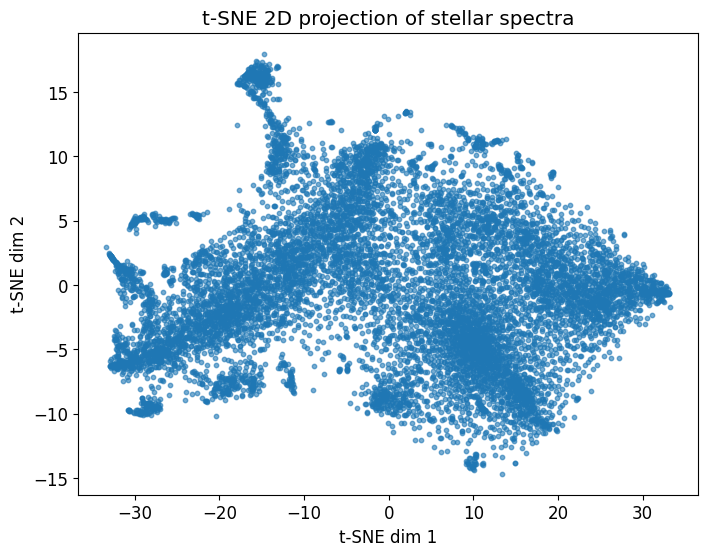

In [34]:
plt.figure(figsize=(8,6))
plt.scatter(X_embedded[:,0], X_embedded[:,1], s=10, alpha=0.6)
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.title('t-SNE 2D projection of stellar spectra')
plt.grid(False)
plt.show()